In [1]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer

from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder

from qiskit.visualization import plot_histogram, plot_circuit_layout, plot_state_city
from qiskit.circuit.classical import expr
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay, PassManager
from qiskit.qasm2 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
token = "9zsMDJr2D381yK6A2fmx2Aqq4mnVaD9RA0Uh49It39UF"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", instance="free")

# hw_name = "ibm_brisbane"
hw_name = "ibm_fez"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
    )

## change later back to 3
pm_ideal = generate_preset_pass_manager(
    optimization_level=3, backend=sim_ideal
    #, seed_transpiler=12345
    )

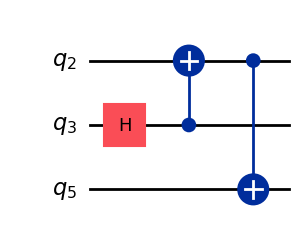

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

qc = QuantumCircuit(6)
qc.h(3)
qc.cx(3, 2)
qc.barrier([2,3,5])
qc.cx(2, 5)
qc.draw("mpl", idle_wires=False, plot_barriers=False)


In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.draw("mpl")

ZZ = SparsePauliOp('ZZZ')
ZI = SparsePauliOp('ZII')
IX = SparsePauliOp('IXI')
IZ = SparsePauliOp('IZI')
XI = SparsePauliOp('XII')
XX = SparsePauliOp('XXX')
observables = [IZ, IX, ZI, XI, ZZ, XX]


In [4]:
from qiskit.quantum_info import Pauli
p = Pauli('XZ')
print(p.to_matrix())

[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]]


In [5]:
p = Pauli('-ZX')
print(p.to_matrix())

[[ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.-0.j]
 [ 0.+0.j  0.+0.j  1.-0.j  0.+0.j]]


In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Recreate the circuit from your image
qc = QuantumCircuit(1)
qc.reset(0)
qc.rx(np.pi/2, 0)
qc.rz(np.pi/2, 0)
qc.ry(np.pi/2, 0)
qc.measure_all()

# 2. Use the AerSimulator to run the circuit
simulator = AerSimulator()
# We run it for a large number of shots to get an accurate probability
result = simulator.run(qc, shots=10000).result()
counts = result.get_counts()

# 3. Calculate the probability of measuring '1'
prob_1 = counts.get('0', 0) / 10000

print(f"Counts: {counts}")
print(f"Approximate probability of measuring 1: {prob_1}")

Counts: {'1': 10000}
Approximate probability of measuring 1: 0.0


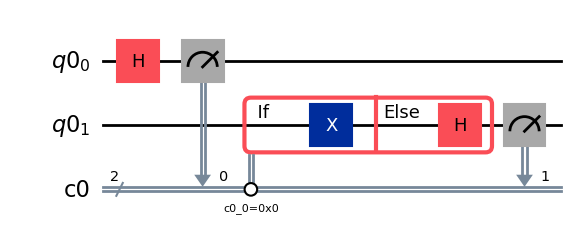

In [7]:
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)
(q0, q1) = qubits
(c0, c1) = clbits

circuit.h(q0)
circuit.measure(q0, c0)
with circuit.if_test((c0, 0)) as else_:
    circuit.x(q1)
with else_:
    circuit.h(q1)
circuit.measure(q1, c1)

circuit.draw("mpl")

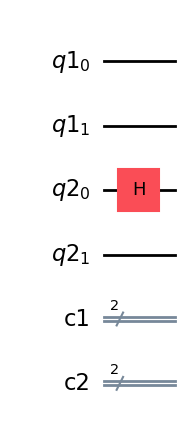

In [8]:
qubits_1 = QuantumRegister(2)
qubits_2 = QuantumRegister(2)
clbits_1 = ClassicalRegister(2)
clbits_2 = ClassicalRegister(2)
circuit = QuantumCircuit(qubits_1, qubits_2, clbits_1, clbits_2)

circuit.h(2)
circuit.draw("mpl")

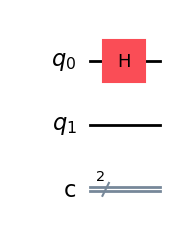

In [9]:
circuit = QuantumCircuit(2, 2)

circuit.h(0)
circuit.draw("mpl")

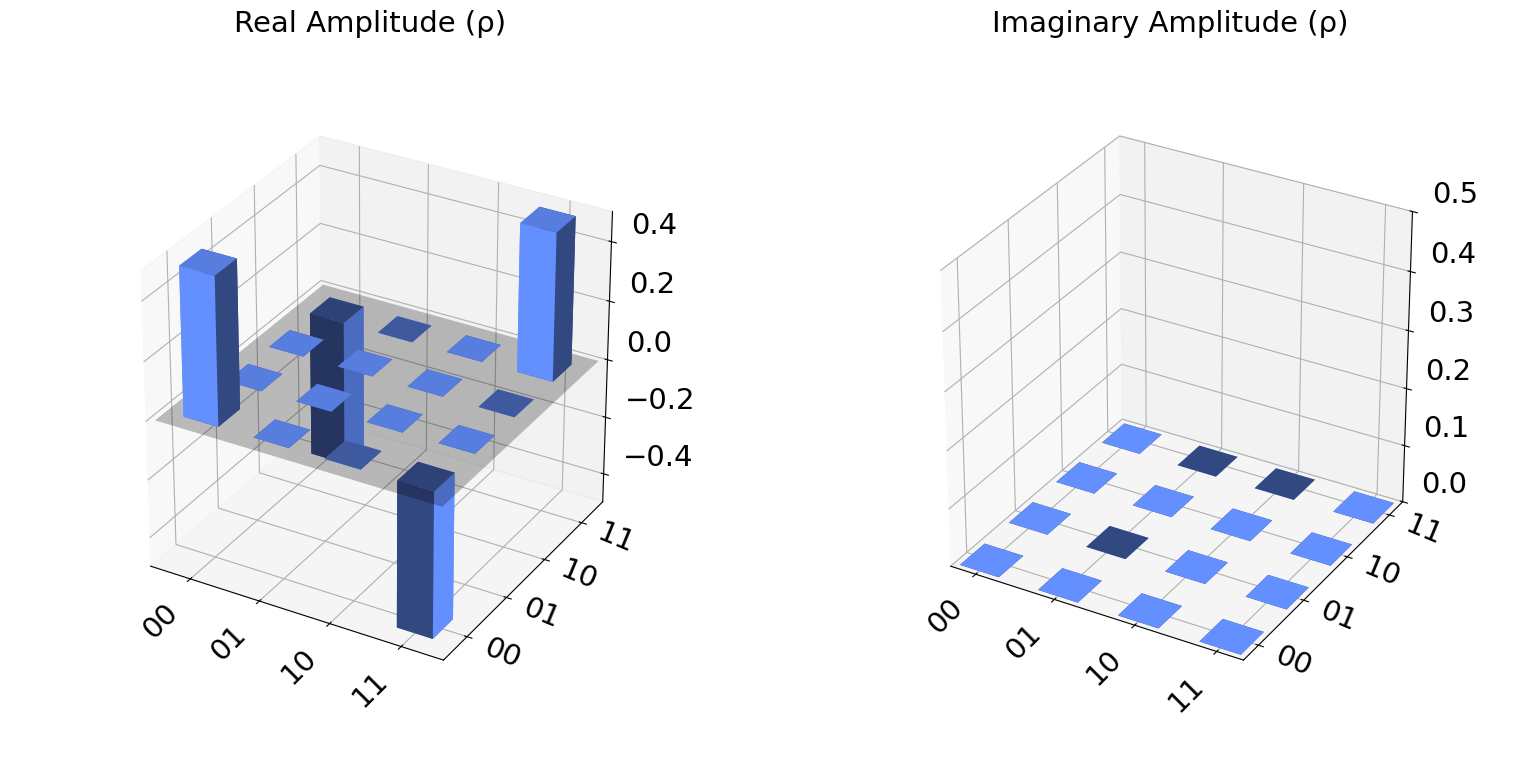

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_paulivec

qc = QuantumCircuit(2)
qc.h(0)
qc.z(0)
qc.cx(0,1)

# plot using a Statevector
state = Statevector(qc)
plot_state_city(state)

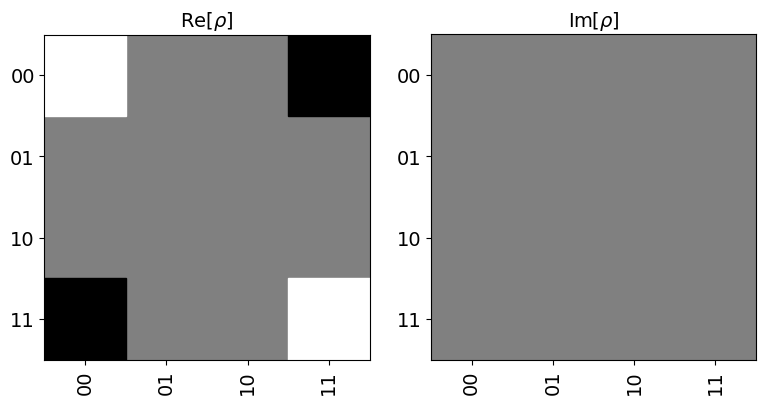

In [11]:
plot_state_hinton(state)

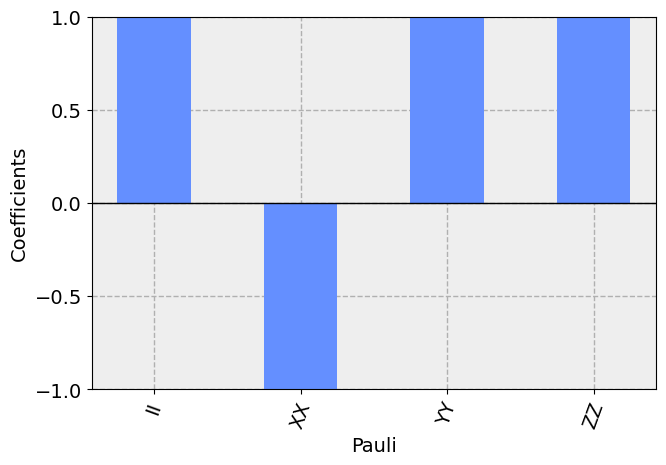

In [12]:
plot_state_paulivec(state)

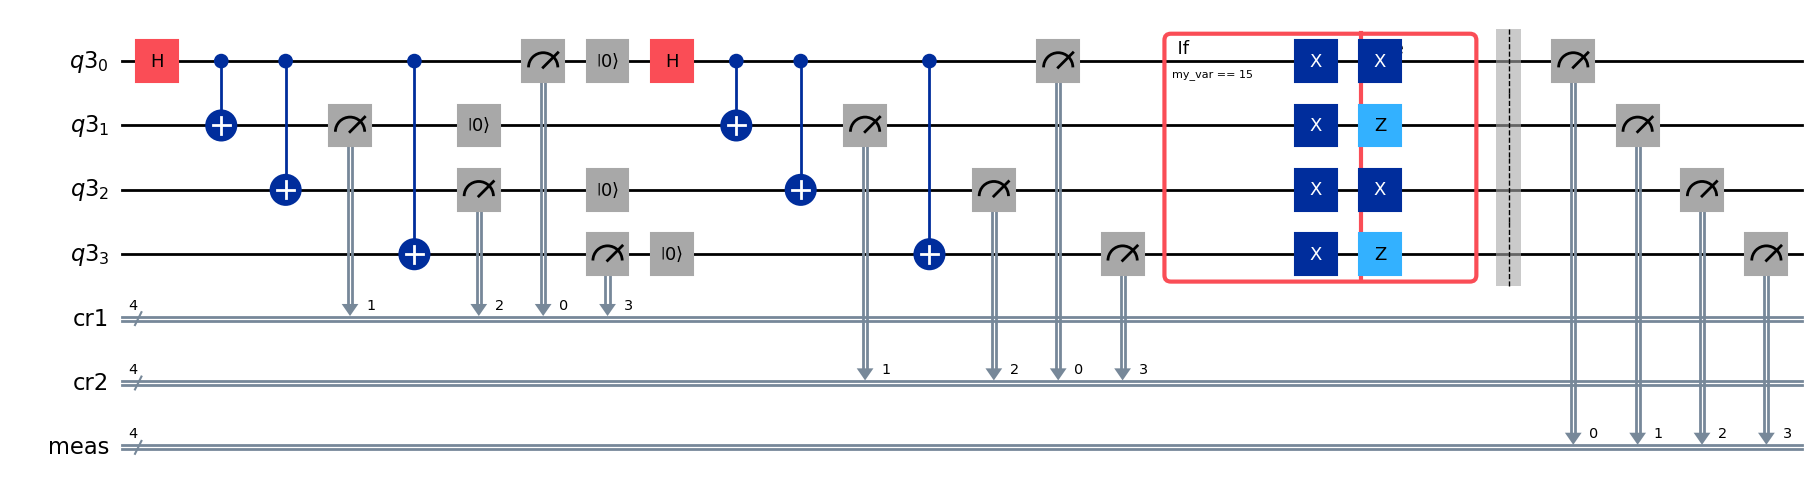

In [13]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr, types

my_var = expr.Var.new("my_var", types.Uint(4))

cr1 = ClassicalRegister(4, "cr1")
cr2 = ClassicalRegister(4, "cr2")
qc = QuantumCircuit(QuantumRegister(4), cr1, cr2)

# Get some measurement results into each register.
qc.h(0)
for i in range(1, 4):
    qc.cx(0, i)
qc.measure(range(4), cr1)

qc.reset(range(4))
qc.h(0)
for i in range(1, 4):
    qc.cx(0, i)
qc.measure(range(4), cr2)

# Now when we add the variable, it is initialized using the real-time state of the
# two classical registers we measured into above.
# qc.add_var(my_var, expr.bit_not(cr1, cr2))
qc.add_var(my_var, expr.bit_and(cr1, cr2))

# 2. Use expr.equal() to evaluate the Var object
with qc.if_test(expr.equal(my_var, 15)) as else_:
    qc.x(0)
    qc.x(1)
    qc.x(2)
    qc.x(3)
with else_:
    qc.x(0)
    qc.z(1)
    qc.x(2)
    qc.z(3)

from qiskit_aer import AerSimulator

# # Add a conditional X gate: Only flip qubit 0 if my_var equals 15 (binary 1111)

# Measure the result of that conditional gate
qc.measure_all()

# # Run the simulation
# backend = AerSimulator()
# job = backend.run(qc)
# counts = job.result().get_counts()
# print(counts)

qc.draw("mpl", fold=-1)


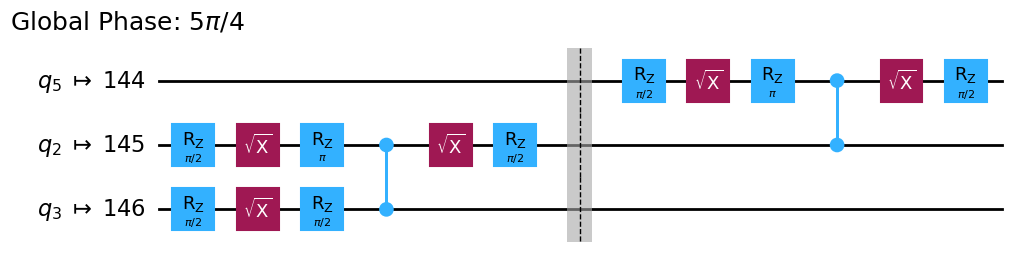

In [14]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

qc = QuantumCircuit(6)
qc.h(3)
qc.cx(3, 2)
qc.barrier([2,3,5])
qc.cx(2, 5)
qc.draw("mpl", idle_wires=False, plot_barriers=False)

tqc = pm.run(qc)
tqc.draw("mpl", fold=-1)


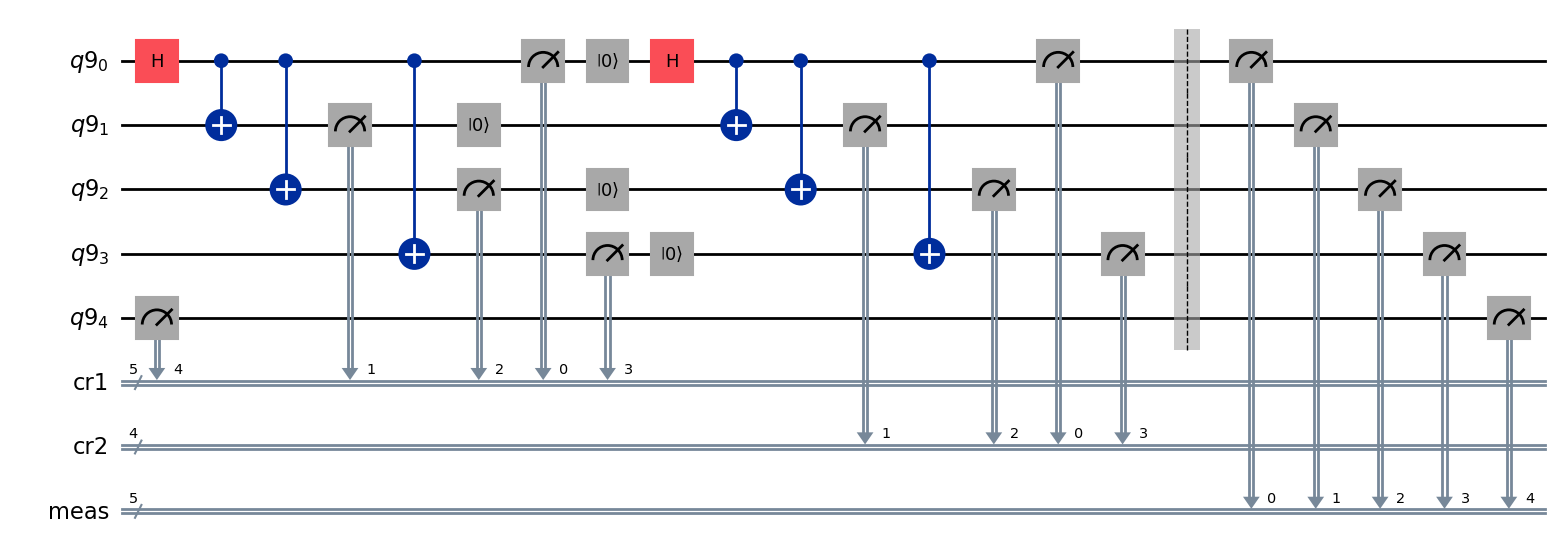

In [27]:
tqc = pm_ideal.run(qc)
tqc.draw("mpl", fold=-1)

In [6]:
transpiled_obs = []
for obs in observables:
    transpiled_obs.append(obs.apply_layout(layout=tqc.layout))

In [10]:
pm = generate_preset_pass_manager(optimization_level=3, backend=sim_ideal)
isa_circuit = pm.run(tqc)
# isa_observable = observable.apply_layout(isa_circuit.layout)
 
precision = 0.015625  / 10
estimator = Estimator(mode=sim_ideal)
job = estimator.run([(isa_circuit, observables, None, 0.015625)], precision=precision)
result = job.result()

print(f">>> {result}")

for res in result:
    print(f"  > Expectation value: {res.data.evs}")
    print(f"  > Metadata: {res.metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(6,), dtype=float64>), stds=np.ndarray(<shape=(6,), dtype=float64>), shape=(6,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
  > Expectation value: [0.02783203 0.01318359 0.02783203 0.         0.02783203 1.        ]
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


In [11]:
import numpy as np
 
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
 
 
# Step 1: Map classical inputs to a quantum problem
theta = Parameter("θ")
 
chsh_circuit = QuantumCircuit(2)
chsh_circuit.h(0)
chsh_circuit.cx(0, 1)
chsh_circuit.ry(theta, 0)
 
number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)
individual_phases = [[ph] for ph in phases]
 
ZZ = SparsePauliOp.from_list([("ZZ", 1)])
ZX = SparsePauliOp.from_list([("ZX", 1)])
XZ = SparsePauliOp.from_list([("XZ", 1)])
XX = SparsePauliOp.from_list([("XX", 1)])
ops = [ZZ, ZX, XZ, XX]
 
# Step 2: Optimize problem for quantum execution.
 
pm = generate_preset_pass_manager(backend=sim_ideal, optimization_level=1)
chsh_isa_circuit = pm.run(chsh_circuit)
isa_observables = [
    operator.apply_layout(chsh_isa_circuit.layout) for operator in ops
]
 
# Step 3: Execute using Qiskit primitives.
 
# Reshape observable array for broadcasting
reshaped_ops = np.fromiter(isa_observables, dtype=object)
reshaped_ops = reshaped_ops.reshape((4,1))

# reshaped_par = np.fromiter(individual_phases, dtype=object)
# reshaped_par = reshaped_par.reshape((3, 7))

 
estimator = Estimator(sim_ideal, options={"default_shots": int(1e4)})
job = estimator.run([(chsh_isa_circuit, reshaped_ops, individual_phases)])
# Get results for the first (and only) PUB
pub_result = job.result()[0]
# print(f">>> Expectation values: {pub_result.data.evs}")
print(f">>> Standard errors: {pub_result.data.stds}")
print(f">>> Metadata: {pub_result.metadata}")

>>> Standard errors: [[0.         0.00338407 0.0059544  0.00820254 0.00951127 0.00999939
  0.00952416 0.00806525 0.00576354 0.0030297  0.         0.00307958
  0.00586154 0.00813761 0.0095745  0.00999913 0.00949885 0.00809587
  0.00593275 0.00314069 0.        ]
 [0.00999988 0.00952032 0.00812041 0.0059517  0.00314069 0.
  0.00314069 0.00588908 0.00806378 0.00951645 0.00999991 0.00950082
  0.00804022 0.0059517  0.00318865 0.         0.0031103  0.00587533
  0.00814332 0.00952672 0.00999993]
 [0.00999771 0.00946262 0.00809587 0.00596248 0.0031225  0.
  0.00305475 0.00589731 0.00808133 0.00946262 0.00999978 0.00951967
  0.00800749 0.00598129 0.00301709 0.         0.00293367 0.00585046
  0.00814616 0.00949092 0.00999875]
 [0.         0.00295315 0.00583657 0.00805202 0.00952288 0.00999995
  0.00955928 0.0081547  0.00580584 0.00301076 0.         0.00315276
  0.00591643 0.00820532 0.00949489 0.00999849 0.00947215 0.00806525
  0.0057064  0.00315877 0.        ]]
>>> Metadata: {'target_precision':

In [12]:
result = job.result()


In [13]:
len(result[0].data.evs)

4

In [14]:
len(result[0].data.evs[0])

21

# Investigate between Torino and Marrakesh

In [15]:
from wrappers.stim_wrapper import (get_backend_information)

hw_name = "ibm_torino"
backend = service.backend(hw_name)

t1_torino, t2_torino, error_1q_torino, readout_error_torino, error_2q_torino = get_backend_information(backend)

hw_name = "ibm_marrakesh"
backend = service.backend(hw_name)

t1_marrakesh, t2_marrakesh, error_1q_marrakesh, readout_error_marrakesh, error_2q_marrakesh = get_backend_information(backend)

hw_name = "ibm_fez"
backend = service.backend(hw_name)

t1_fez, t2_fez, error_1q_fez, readout_error_fez, error_2q_fez = get_backend_information(backend)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to convert your dicts into a clean DataFrame
def create_backend_df(name, t1, t2, e1q, read_err, e2q, initial_layout, used_edges):
    # --- Single Qubit Metrics ---
    # We assume keys are qubit indices (0, 1, 2...)
    data_1q = []
    # all_qubits = set(t1.keys()) | set(t2.keys())
    
    for q in initial_layout:
        data_1q.append({
            "Backend": name,
            "Qubit": q,
            "T1 (us)": t1.get(q, 0) * 1e6, # Convert seconds to microseconds for readability
            "T2 (us)": t2.get(q, 0) * 1e6,
            "Readout Error": read_err.get(q, 0),
            "1Q Gate Error": e1q.get(q, 0)
        })
    df_1q = pd.DataFrame(data_1q)

    # --- Two Qubit Metrics ---
    # We assume keys are tuples/edges like (0, 1)
    data_2q = []
    for edge, error in e2q.items():

        # if edge[0] in initial_layout or edge[1] in initial_layout:
        if edge in used_edges:
            data_2q.append({
                "Backend": name,
                "Edge": str(edge), # Convert tuple to string for plotting
                "CZ Gate Error": error
            })
    df_2q = pd.DataFrame(data_2q)
    
    return df_1q, df_2q



# 1. Create DataFrames for both machines
# (Assuming you have the variables from your snippet loaded)
initial_qubit_torino = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 34, 35, 38, 39, 40, 44]
initial_qubit_marrakesh = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 36, 37, 41, 43, 44, 45, 53, 54, 139, 155]
initial_qubit_fez = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 36, 37, 41, 45, 46, 47, 114, 115, 123, 136]

used_edges_torino = [(0, 15), (1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (16, 23), (17, 27), (19, 20), (21, 22), (24, 25), (28, 29), (34, 40), (38, 39)]
used_edges_marrakesh = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (16, 23), (17, 27), (21, 22), (24, 25), (28, 29), (36, 41), (37, 45), (43, 44), (53, 54), (139, 155)]
used_edges_fez = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (16, 23), (17, 27), (21, 22), (24, 25), (28, 29), (36, 41), (37, 45), (46, 47), (114, 115), (123, 136)]


df_1q_tor, df_2q_tor = create_backend_df("ibm_torino", t1_torino, t2_torino, error_1q_torino, readout_error_torino, error_2q_torino, initial_qubit_torino, used_edges_torino)
df_1q_mar, df_2q_mar = create_backend_df("ibm_marrakesh", t1_marrakesh, t2_marrakesh, error_1q_marrakesh, readout_error_marrakesh, error_2q_marrakesh, initial_qubit_marrakesh, used_edges_marrakesh)
df_1q_fer, df_2q_fer = create_backend_df("ibm_fez", t1_fez, t2_fez, error_1q_fez, readout_error_fez, error_2q_fez, initial_qubit_fez, used_edges_fez)

# 2. Combine them for easy comparison
df_1q_all = pd.concat([df_1q_tor, df_1q_fer, df_1q_mar])
df_2q_all = pd.concat([df_2q_tor, df_2q_fer, df_2q_mar])

In [21]:
df_2q_all

,Backend,Edge,CZ Gate Error
0,ibm_torino,"(0, 15)",0.003890
1,ibm_torino,"(1, 2)",0.003050
2,ibm_torino,"(3, 4)",0.001423
3,ibm_torino,"(5, 6)",0.002295
4,ibm_torino,"(7, 8)",0.001633
5,ibm_torino,"(9, 10)",0.001961
6,ibm_torino,"(11, 12)",0.004175
7,ibm_torino,"(16, 23)",0.004454
8,ibm_torino,"(17, 27)",0.003738
9,ibm_torino,"(19, 20)",0.004075


In [22]:
print("--- Single Qubit Metrics Comparison (Median) ---")
print(df_1q_all.groupby("Backend")[["T1 (us)", "T2 (us)", "Readout Error", "1Q Gate Error"]].mean())

print("\n--- Two Qubit Gate Error Comparison (Median) ---")
print(df_2q_all.groupby("Backend")[["CZ Gate Error"]].median())

--- Single Qubit Metrics Comparison (Median) ---
                  T1 (us)     T2 (us)  Readout Error  1Q Gate Error
Backend                                                            
ibm_fez        147.394203  112.558774       0.020348       0.000555
ibm_marrakesh  228.580810  153.315682       0.012955       0.000472
ibm_torino     162.558205  140.401153       0.040424       0.000603

--- Two Qubit Gate Error Comparison (Median) ---
               CZ Gate Error
Backend                     
ibm_fez             0.002835
ibm_marrakesh       0.002089
ibm_torino          0.003050


/tmp/ipykernel_709069/4129968182.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_709069/4129968182.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


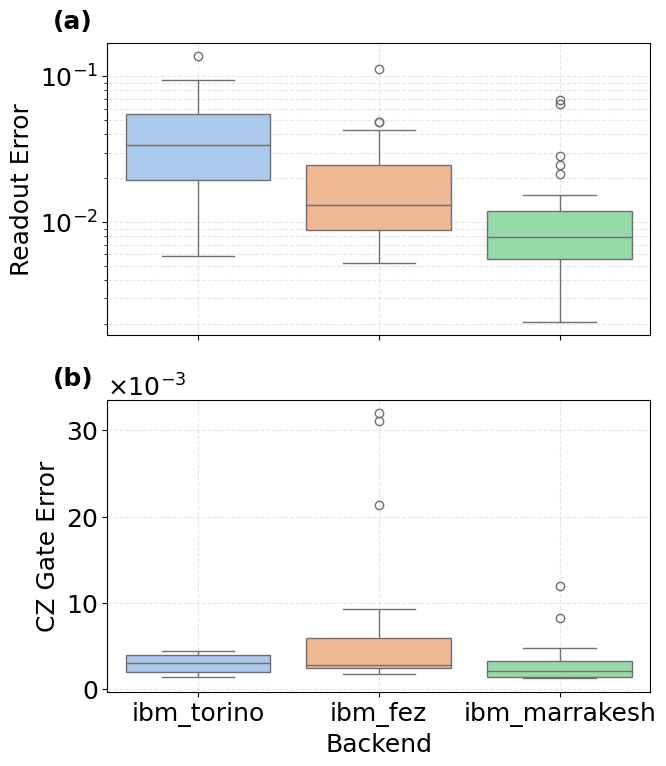

In [23]:
import matplotlib.ticker as ticker
import pandas as pd

def plot_comparison(df, metric, title):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="Backend", y=metric, palette="pastel")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# # Visualize Coherence (Higher is better)
# plot_comparison(df_1q_all, "T1 (us)", "T1 Relaxation Time (Higher is Better)")
# plot_comparison(df_1q_all, "T2 (us)", "T2 Dephasing Time (Higher is Better)")

# Visualize Errors (Lower is better)
# We use log scale for errors because they can vary by orders of magnitude
# ---------------------------------------------------------
# 2. PLOTTING: Stacked subplots
# ---------------------------------------------------------
# figsize=(6, 8) gives a good vertical aspect ratio for two plots
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# --- Plot (a): Readout Error ---
sns.boxplot(
    data=df_1q_all, 
    x="Backend", 
    y="Readout Error", 
    palette="pastel", 
    ax=axes[0]
)
axes[0].set_yscale('log') # Log scale is good here (spanning 10^-2 to 10^-1)
axes[0].set_ylabel("Readout Error")
axes[0].set_xlabel("") # Hide x-label for the top plot
axes[0].tick_params(axis='both')
axes[0].grid(True, which="both", ls="--", alpha=0.3) # Optional: faint grid helps read log scale

# Add (a) label
axes[0].text(-0.1, 1.05, '(a)', transform=axes[0].transAxes, fontweight='bold')


# --- Plot (b): CZ Gate Error ---
sns.boxplot(
    data=df_2q_all, 
    x="Backend", 
    y="CZ Gate Error", 
    palette="pastel", 
    ax=axes[1]
)

# NOTE: For small ranges (2e-3 to 6e-3), Linear scale is usually better 
# than Log because Log compresses the visual difference.
axes[1].set_yscale('linear') 

# Format Y-axis to standard scientific notation (e.g., 2.0, 3.0 x 10^-3)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, -3)) # Forces the x10^-3 label
axes[1].yaxis.set_major_formatter(formatter)

axes[1].set_ylabel("CZ Gate Error")
axes[1].set_xlabel("Backend")
axes[1].tick_params(axis='both')
axes[1].grid(True, which="major", ls="--", alpha=0.3)

# Add (b) label
axes[1].text(-0.1, 1.05, '(b)', transform=axes[1].transAxes, fontweight='bold')

# ---------------------------------------------------------
# 3. SAVING
# ---------------------------------------------------------
plt.tight_layout()
plt.savefig("polar_n4_error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()